# Outliers

Outliers are data points that are significantly different from the rest of the data. They can be unusually high or unusually low compared to other values in a dataset.

### Why Outliers Matter
Outliers can strongly affect machine learning models:
- They can **skew statistical measures** like mean and standard deviation  
- They may **reduce model accuracy** by misleading the learning process  
- Some models (like linear regression) are **very sensitive** to outliers, while others (like tree-based models) are more robust  

### Causes of Outliers
Outliers may occur due to:
- Data entry or measurement errors  
- Natural variation in data  
- Rare but valid observations  

### Handling Outliers
Common approaches include:
- **Removing** them if they are errors  
- **Capping or clipping** extreme values  
- **Transforming** data (e.g., log transformation)  
- Using **robust models** that are less affected by outliers  

> Not all outliers are bad — some contain important information. Always understand the data before deciding how to handle them.

---

## Dataset Used

We are using the Titanic dataset available in seaborn

This dataset contains information about passengers such as age, gender, class, and whether they survived or not.

In [2]:
import seaborn as sns
df = sns.load_dataset("titanic")

---

## Basic Data Overview

In [3]:
df.info()
df.describe()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 15 columns):
 #   Column       Non-Null Count  Dtype   
---  ------       --------------  -----   
 0   survived     891 non-null    int64   
 1   pclass       891 non-null    int64   
 2   sex          891 non-null    object  
 3   age          714 non-null    float64 
 4   sibsp        891 non-null    int64   
 5   parch        891 non-null    int64   
 6   fare         891 non-null    float64 
 7   embarked     889 non-null    object  
 8   class        891 non-null    category
 9   who          891 non-null    object  
 10  adult_male   891 non-null    bool    
 11  deck         203 non-null    category
 12  embark_town  889 non-null    object  
 13  alive        891 non-null    object  
 14  alone        891 non-null    bool    
dtypes: bool(2), category(2), float64(2), int64(4), object(5)
memory usage: 80.7+ KB


,survived,pclass,age,sibsp,parch,fare
count,891.000000,891.000000,714.000000,891.000000,891.000000,891.000000
mean,0.383838,2.308642,29.699118,0.523008,0.381594,32.204208
std,0.486592,0.836071,14.526497,1.102743,0.806057,49.693429
min,0.000000,1.000000,0.420000,0.000000,0.000000,0.000000
25%,0.000000,2.000000,20.125000,0.000000,0.000000,7.910400
50%,0.000000,3.000000,28.000000,0.000000,0.000000,14.454200
75%,1.000000,3.000000,38.000000,1.000000,0.000000,31.000000
max,1.000000,3.000000,80.000000,8.000000,6.000000,512.329200


### `df.info()`
This function provides a quick summary of the dataset:
- Total number of rows and columns  
- Column names  
- Data types of each column  
- Number of non-null (non-missing) values  
- Memory usage  

**Key Observations:**
- Some columns have missing values (e.g., `age`, `embarked`, `deck`)  
- Dataset contains different data types: numerical, categorical, and boolean  

### `df.describe()`
This function shows statistical summary for numerical columns:
- **count** → number of non-null values  
- **mean** → average value  
- **std** → standard deviation (spread of data)  
- **min / max** → smallest and largest values  
- **25%, 50%, 75%** → quartiles (used to understand distribution)  

**Key Observations:**
- Features like `fare`, `sibsp`, and `parch` show large variation  
- Maximum values are much higher than the 75th percentile in some columns (e.g., `fare`), which may indicate **possible outliers**  

### Key Point
This step helps us understand data structure, detect missing values, and identify potential outliers before further analysis.

---

## Outlier Detection using IQR Method

In [4]:
col = "fare"  
Q1 = df[col].quantile(0.25)
Q3 = df[col].quantile(0.75)
IQR = Q3 - Q1

lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR

outliers_iqr = df[(df[col] < lower_bound) | (df[col] > upper_bound)]

print("Number of outliers (IQR):", len(outliers_iqr))
outliers_iqr.head()

Number of outliers (IQR): 116


,survived,pclass,sex,age,sibsp,parch,fare,embarked,class,who,adult_male,deck,embark_town,alive,alone
1,1,1,female,38.0,1,0,71.2833,C,First,woman,False,C,Cherbourg,yes,False
27,0,1,male,19.0,3,2,263.0000,S,First,man,True,C,Southampton,no,False
31,1,1,female,NaN,1,0,146.5208,C,First,woman,False,B,Cherbourg,yes,False
34,0,1,male,28.0,1,0,82.1708,C,First,man,True,NaN,Cherbourg,no,False
52,1,1,female,49.0,1,0,76.7292,C,First,woman,False,D,Cherbourg,yes,False


In this step, we detect outliers using the **Interquartile Range (IQR)** method.

### What is IQR?
IQR measures the spread of the middle 50% of the data:
- **Q1 (25th percentile)** → lower quartile  
- **Q3 (75th percentile)** → upper quartile  
- **IQR = Q3 - Q1**

### Outlier Formula
A data point is considered an outlier if:
- It is **less than (Q1 - 1.5 × IQR)**  
- It is **greater than (Q3 + 1.5 × IQR)**  

### What the Code Does
- Selects the column (`fare`)  
- Calculates Q1 and Q3  
- Computes IQR  
- Defines lower and upper bounds  
- Filters data points outside these bounds as outliers  

### Key Observation
- Several rows have very high `fare` values compared to most data  
- These extreme values are identified as **outliers**  

### Key Point
The IQR method is simple and effective for detecting outliers, especially when the data is not normally distributed.

---

## Outlier Detection using Z-Score Method

In [7]:
import numpy as np
from scipy import stats
z = np.abs(stats.zscore(df[col].dropna()))
outliers_z = df[z > 3]
print("Number of outliers (Z-score):", len(outliers_z))
outliers_z.head()

Number of outliers (Z-score): 20


,survived,pclass,sex,age,sibsp,parch,fare,embarked,class,who,adult_male,deck,embark_town,alive,alone
27,0,1,male,19.0,3,2,263.0000,S,First,man,True,C,Southampton,no,False
88,1,1,female,23.0,3,2,263.0000,S,First,woman,False,C,Southampton,yes,False
118,0,1,male,24.0,0,1,247.5208,C,First,man,True,B,Cherbourg,no,False
258,1,1,female,35.0,0,0,512.3292,C,First,woman,False,NaN,Cherbourg,yes,True
299,1,1,female,50.0,0,1,247.5208,C,First,woman,False,B,Cherbourg,yes,False


In this step, we detect outliers using the **Z-score** method.

### What is Z-Score?
Z-score measures how far a data point is from the mean in terms of standard deviations.

- Formula:  
  **Z = (X - Mean) / Standard Deviation**

### Outlier Rule
A data point is considered an outlier if:
- **Z-score > 3** or **Z-score < -3**

### What the Code Does
- Computes Z-scores for the selected column (`fare`)  
- Uses absolute values to consider both high and low extremes  
- Filters data points where Z-score is greater than 3  
- Displays detected outliers  

### Key Observation
- A small number of rows have very high `fare` values  
- These values are far from the mean and are detected as outliers  

### Key Point
Z-score method works well when data is approximately normally distributed, but may be less effective for skewed data.
                                                                                                    
---

## Visualizing Outliers with a Boxplot

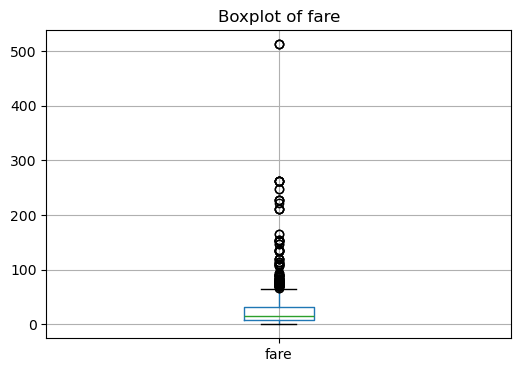

In [9]:
import matplotlib.pyplot as plt
plt.figure(figsize=(6,4))
df.boxplot(column=col)
plt.title(f"Boxplot of {col}")
plt.show()

### What is a Boxplot?
A boxplot graphically displays the distribution of a numerical variable through five summary statistics:
- **Median (middle line)**  
- **Quartiles (box edges: Q1 and Q3)**  
- **Whiskers (range excluding outliers)**  
- **Outliers (points outside whiskers)**  

### What the Plot Shows
- The box represents the middle 50% of `fare` values (IQR)  
- The line inside the box is the median fare  
- Whiskers extend to values within 1.5 × IQR from the quartiles  
- Circles above whiskers indicate **outliers** with unusually high fares  

### Key Point
Boxplots are a simple, effective way to visually identify outliers and understand data spread.

---

## Removing Outliers from the Dataset

In [10]:
df_clean = df[(df[col] >= lower_bound) & (df[col] <= upper_bound)]
print("Original shape:", df.shape)
print("Cleaned shape:", df_clean.shape)

Original shape: (891, 15)
Cleaned shape: (775, 15)


### What the Code Does
- Filters the dataset to keep only rows where the `fare` value lies **within the IQR-based bounds** (between `lower_bound` and `upper_bound`)  
- Removes outliers identified by the IQR method  

### Outcome
- The original dataset has 891 rows  
- After removing outliers, the cleaned dataset has 775 rows  

### Key Point
Removing outliers can help improve model performance by reducing noise and extreme values, but it also reduces data size—so use this step thoughtfully.

---

## Comparing Data Before and After Outlier Removal

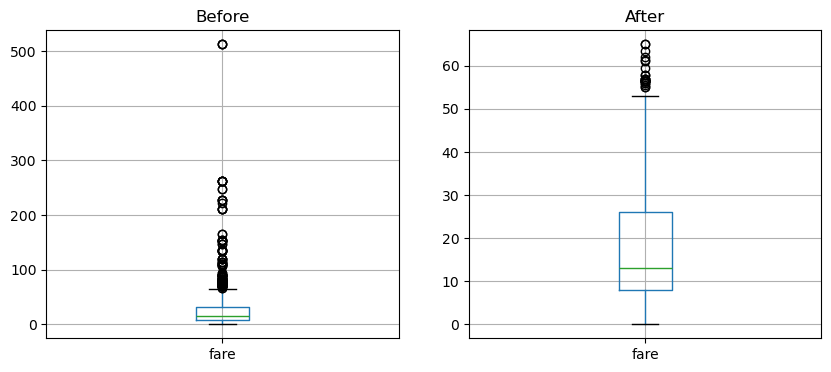

In [12]:
plt.figure(figsize=(10,4))

plt.subplot(1,2,1)
df.boxplot(column=col)
plt.title("Before")

plt.subplot(1,2,2)
df_clean.boxplot(column=col)
plt.title("After")

plt.show()

### What the Plots Show
- **Before:** The original data has many extreme high values (`fare`), visible as outliers above the whiskers.  
- **After:** After removing outliers using the IQR method, the number and magnitude of extreme values significantly decrease.  

### Key Point
Side-by-side boxplots clearly illustrate how outlier removal reduces data variability and helps create a cleaner dataset for modeling.